# 연령별취업자수관계
- https://kosis.kr/search/search.do
- 행정구역(시도)/성/연령별 취업자 검색

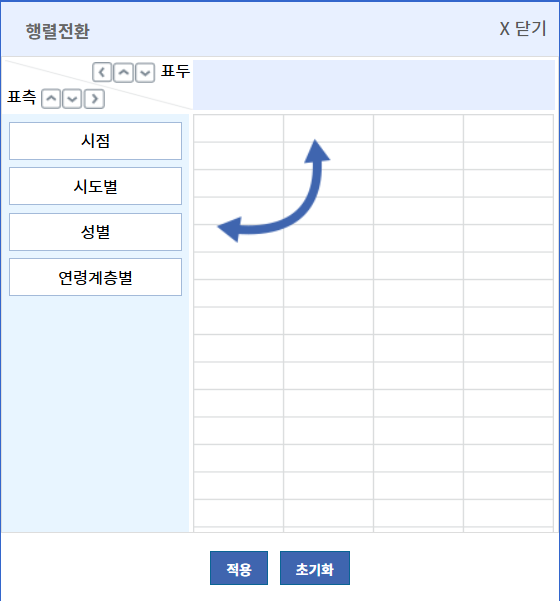

/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/conda/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Text(0.2, 0.4, '한글')

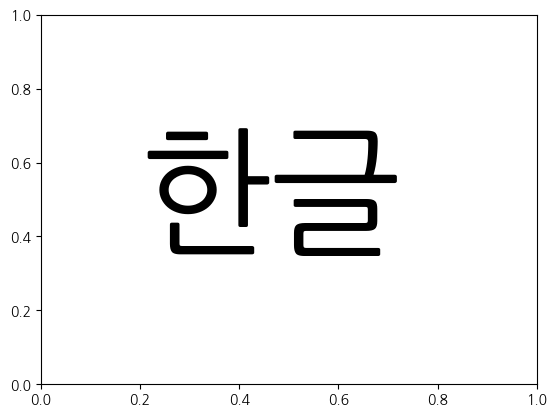

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.text(0.2,0.4, '한글', size=100)

In [3]:
file_path = './dataset/행정구역시도성연령별취업자202606.csv'
raw = pd.read_csv(file_path, encoding="EUC-KR")
raw.head()

,시점,시도별,성별,연령계층별,데이터
0,2015.1/4,서울특별시,남자,20 - 29세,322
1,2015.1/4,서울특별시,남자,30 - 39세,752
2,2015.1/4,서울특별시,남자,40 - 49세,750
3,2015.1/4,서울특별시,남자,50 - 59세,669
4,2015.1/4,서울특별시,남자,60세이상,366


In [7]:
# raw['location'].unique()

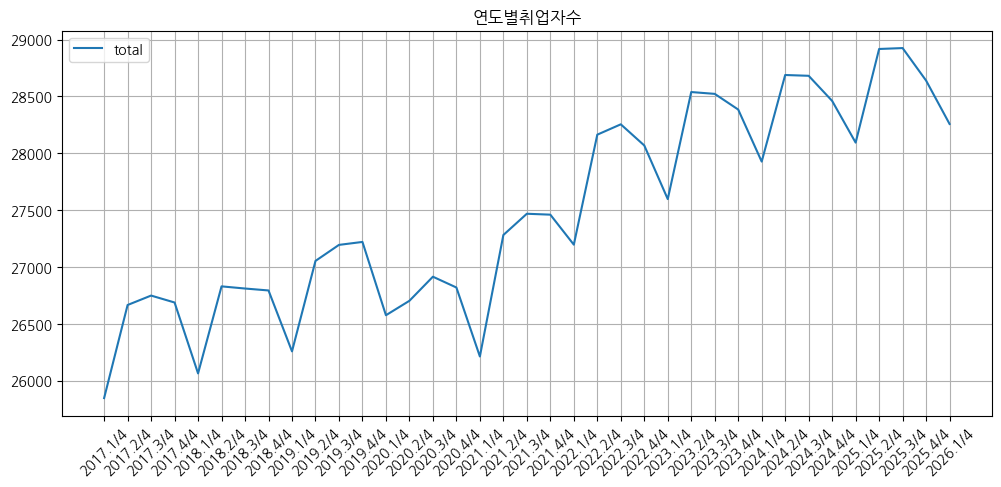

In [8]:
df = raw.copy()
df.columns = ['date', 'location', 'gender', 'age', 'value']

# 방법1
# df.iloc[1360:,:]
# 방법2
gdata = df[df['date'] >= "2017.1/4"].copy()
gdata['value'] = gdata['value'].astype('int')

result = gdata.groupby('date')['value'].sum().reset_index(name='total')
result.plot(figsize=(12,5),title="연도별취업자수")

plt.xticks(range(len(result['date'])), labels=result['date'] , rotation=45)
plt.grid()
plt.show()

# df.loc[df['location'] == '세종특별자치시','value'] = df.loc[df['location'] == '세종특별자치시','value'].replace('-', '0')
# df['value'] = df['value'].astype(int)
# gdata = df.groupby('date')['value'].sum().reset_index(name="total")
# gdata

In [9]:
# 남녀를 구분하여 표를 2중으로 겹처라.
gdata

,date,location,gender,age,value
1360,2017.1/4,서울특별시,남자,20 - 29세,320
1361,2017.1/4,서울특별시,남자,30 - 39세,714
1362,2017.1/4,서울특별시,남자,40 - 49세,734
1363,2017.1/4,서울특별시,남자,50 - 59세,658
1364,2017.1/4,서울특별시,남자,60세이상,394
...,...,...,...,...,...
7645,2026.1/4,제주도,여자,20 - 29세,20
7646,2026.1/4,제주도,여자,30 - 39세,29
7647,2026.1/4,제주도,여자,40 - 49세,41
7648,2026.1/4,제주도,여자,50 - 59세,48
